# Pseudohuérfanas: construcción y recuperación del blanco

Construcción de las **k = 1** (drogas con exactamente un blanco proteico conocido
en una especie), su estratificación en grupos 0–3, el `frank` por especie y la
clasificación de la semilla en *nula / no informativa / informativa*.

Cada droga se **orfaniza**: se le sacan todas sus aristas de bioactividad y se
arma la semilla sólo con su vecindario químico. El blanco verdadero puede volver
por otra droga vecina —eso es inferencia directa y es legítima—, nunca por sí
misma (`comun/tests/test_fuga.py`).

Los parámetros son los óptimos por especie de `genome_prioritization/02`, y la
capa química va **filtrada por promiscuidad** (README §7.3): estos números no son
comparables con los de `gon3/resultados/pseudohuerfanas/`.

Fuente: `tdr-graph/orphan_drugs_v4.ipynb`.
Salidas: `01_<especie>_pseudohuerfanas.csv`, `01_k1_drugs.csv`, `01_resumen_frank.csv`.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

V4 = "/home/ggiordano/TDR/TDR_2026_v4"
sys.path.insert(0, f"{V4}/comun")
sys.path.insert(0, f"{V4}/huerfanas")
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_huerfanas as fh              # el .py de esta carpeta

SALIDAS = tdr.out("huerfanas")
FIGURAS = SALIDAS / "figuras"
NB      = "01"                             # numero de este notebook: prefija todo lo que genere
n_core  = 20

plt = tdr.estilo()
SALIDAS

PosixPath('/home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out')

## Datos

In [2]:
# cluster_consistent=True: `huerfanas/` filtra los positivos/negativos
# inconsistentes a nivel cluster, como orphan_drugs_v4.ipynb.
crudo = tdr.cargar_db(anotaciones=True, quimica=True, cluster_consistent=True)

# README §7.3: el filtro de promiscuidad se APLICA antes de armar ninguna semilla.
# La lista sale de analiceDB/03; si falta, el error dice qué correr.
promiscuos = tdr.compuestos_promiscuos()
datos = tdr.filtrar_capa_quimica(crudo, promiscuos)

optimos = fh.parametros_optimos()          # de genome_prioritization_out/02_*
len(datos.posdt), len(optimos)

· 00_specie_target
· 03_bioactivities_target_compound
· 04a_interpro / 04b_orthomcl
· 01/02 clusters y aristas quimicas (pesado)
filtro de promiscuidad (MW < 150 y N_parentales > 100): 25 compuestos
  sclus 2396103 -> 2396078 (0.00 % removido)
  dds   973 -> 973 (0.00 % removido)


(248457, 16)

## Acondicionamiento

pseudohuerfanas: 60253 drogas, 26 especies, grupos {0: 22375, 1: 17306, 2: 9830, 3: 10742}
16 especies con pseudohuérfanas y parámetros óptimos
  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out/figuras/01_f01_grupos_por_especie.pdf


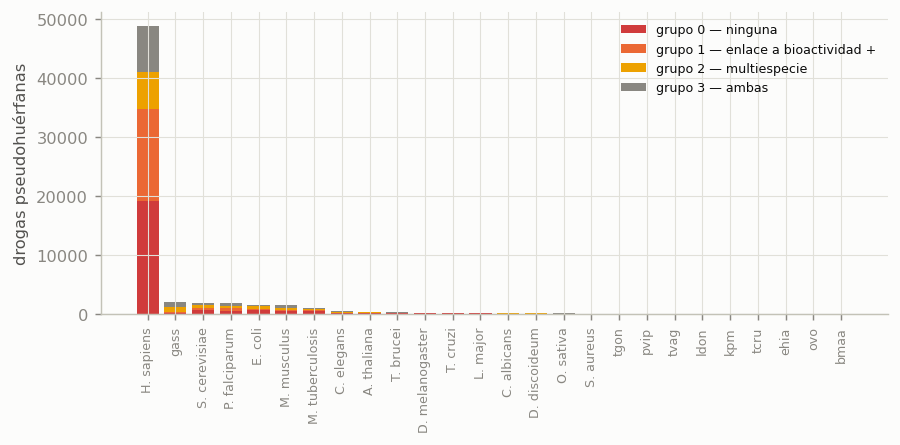

In [3]:
k1, posdt_sp = fh.construir_pseudohuerfanas(datos)
especies = [sp for sp in k1["sp_id"].value_counts().index if sp in optimos]
muestras = {sp: fh.muestra_pseudohuerfanas(k1[k1["sp_id"] == sp], n=fh.N_MUESTRA)
            for sp in especies}

k1.to_csv(SALIDAS / f"{NB}_k1_drugs.csv", index=False)
print(f"{len(especies)} especies con pseudohuérfanas y parámetros óptimos")
fig = fh.fig_grupos(k1, plt)
tdr.guardar(fig, f"{NB}_f01_grupos_por_especie", FIGURAS)

## Corrida

In [4]:
# celda de corrida: el ciclo se lee aca
import time
for sp in especies:
    t0  = time.time()
    ctx = fh.preparar_especie(datos, sp, optimos[sp], k1)         # RS con sus optimos
    fh.fijar_contexto(datos, posdt_sp, ctx)                       # visible por fork
    filas = fh.paralelizar(fh.priorizar_droga, muestras[sp]["drug_id"], n_core=n_core, desc=sp)
    fh.guardar_huerfanas(filas, SALIDAS, NB, sp)                  # -> 01_<sp>_pseudohuerfanas.csv
    print(f"  {sp} en {time.time() - t0:.0f} s", flush=True)

fh.escribir_meta(SALIDAS, NB, notebook="01_pseudohuerfanas.ipynb",
                 params={"optimos": optimos, "n_muestra": fh.N_MUESTRA, "rseed": fh.RSEED},
                 n_core=n_core, especies=especies,
                 filtro_promiscuidad=True, n_promiscuos=len(promiscuos))

[hsap] 1000 tareas en 20 procesos
  hsap: 100/1000
  hsap: 200/1000
  hsap: 300/1000
  hsap: 400/1000
  hsap: 500/1000
  hsap: 600/1000
  hsap: 700/1000
  hsap: 800/1000
  hsap: 900/1000
  hsap: 1000/1000
  hsap: 1000 drogas -> 01_hsap_pseudohuerfanas.csv  (frank<0.1 en 3.5%, semilla {'nula': 841, 'no informativa': 124, 'informativa': 35})
  hsap en 118 s
[scer] 1000 tareas en 20 procesos
  scer: 100/1000
  scer: 200/1000
  scer: 300/1000
  scer: 400/1000
  scer: 500/1000
  scer: 600/1000
  scer: 700/1000
  scer: 800/1000
  scer: 900/1000
  scer: 1000/1000
  scer: 1000 drogas -> 01_scer_pseudohuerfanas.csv  (frank<0.1 en 1.8%, semilla {'nula': 816, 'no informativa': 165, 'informativa': 19})
  scer en 123 s
[pfal] 1000 tareas en 20 procesos
  pfal: 100/1000
  pfal: 200/1000
  pfal: 300/1000
  pfal: 400/1000
  pfal: 500/1000
  pfal: 600/1000
  pfal: 700/1000
  pfal: 800/1000
  pfal: 900/1000
  pfal: 1000/1000
  pfal: 1000 drogas -> 01_pfal_pseudohuerfanas.csv  (frank<0.1 en 0.8%, semilla

{'notebook': '01_pseudohuerfanas.ipynb',
 'nb': '01',
 'fecha': '2026-09-07 12:52',
 'params': {'optimos': {'atha': [0.0, 1.0, 0.5, 0.8],
   'calb': [1.2, 1.0, 0.5, 0.8],
   'cele': [0.3, 1.5, 1.0, 0.8],
   'ddis': [0.0, 1.0, 1.0, 0.8],
   'dmel': [0.0, 1.0, 1.0, 0.8],
   'ecol': [1.2, 1.0, 1.0, 0.8],
   'hsap': [0.0, 0.5, 1.0, 0.8],
   'lmaj': [0.0, 1.5, 0.5, 0.8],
   'mmus': [0.3, 1.0, None, 0.8],
   'mtub': [1.2, 1.0, None, 0.8],
   'osat': [1.2, 1.0, 0.5, 0.8],
   'pfal': [1.2, 1.0, 1.0, 0.8],
   'sao': [0.3, 0.5, 0.5, 0.8],
   'scer': [0.9, 0.0, 0.0, 0.8],
   'tbrt': [0.3, 1.5, None, 0.8],
   'tcr': [0.0, 1.0, 1.0, 0.8]},
  'n_muestra': 1000,
  'rseed': 123457},
 'n_core': 20,
 'tablas_db': {'00_specie_target.csv': '2026-06-05',
  '00_specie_target_full.csv': '2026-06-05',
  '01_clusters_fingerprint.csv': '2026-05-13',
  '01_deleted_compounds.csv': '2026-05-13',
  '01_edges_clusters_fingerprint.csv': '2026-05-13',
  '02_clusters_subestructure.csv': '2026-05-13',
  '02_edges_cluste

# Resultados

In [5]:
res = fh.cargar_resultados(SALIDAS, NB, patron="*_pseudohuerfanas")
res = res.merge(k1[["drug_id", "sp_id", "grupo"]].rename(columns={"sp_id": "especie"}),
                on=["drug_id", "especie"], how="left")
resumen = fh.resumen_frank(res)
resumen.to_csv(SALIDAS / f"{NB}_resumen_frank.csv", index=False)
resumen[resumen["particion"].isin(["total", "semilla", "grupo"])].round(1)

,corte,particion,valor,n,pct_recuperadas,pct_sin_semilla
0,0.1,total,todas,7782,2.6,83.1
1,0.1,grupo,0,2577,0.8,90.1
2,0.1,grupo,1,1494,1.5,87.8
3,0.1,grupo,2,2066,4.2,76.2
4,0.1,grupo,3,1645,4.6,76.7
5,0.1,semilla,informativa,207,99.0,0.0
6,0.1,semilla,no informativa,1105,0.0,0.0
7,0.1,semilla,nula,6470,0.0,100.0


  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out/figuras/01_f02_frank_por_grupo.pdf


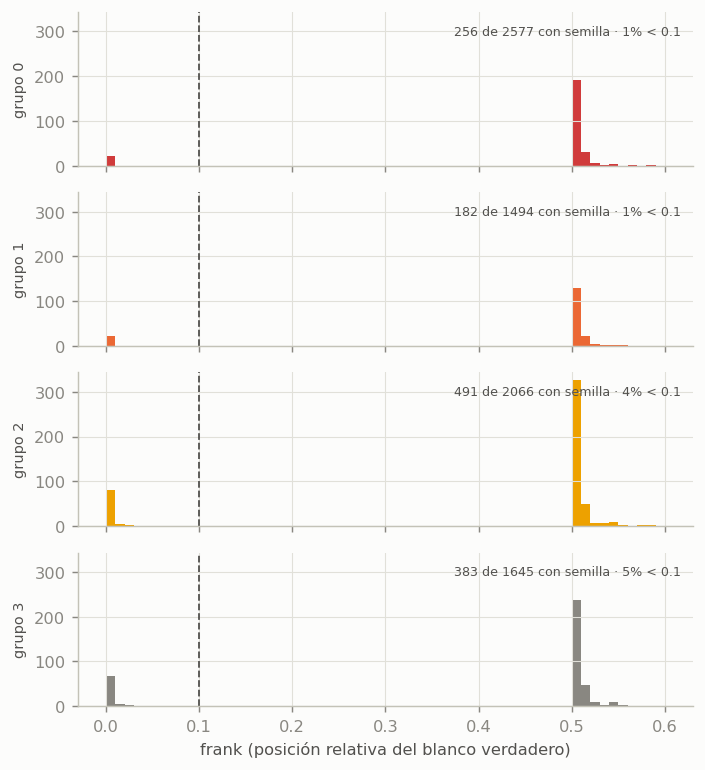

In [6]:
fig = fh.fig_frank(res, plt)
tdr.guardar(fig, f"{NB}_f02_frank_por_grupo", FIGURAS)

  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out/figuras/01_f03_semilla_por_especie.pdf


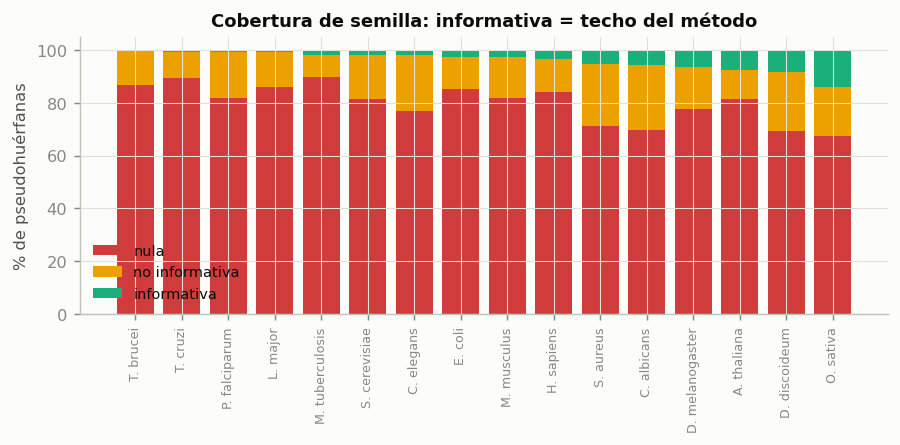

In [7]:
# El cuello de botella: la clase de semilla, no la reponderación
fig = fh.fig_cobertura(res, plt)
tdr.guardar(fig, f"{NB}_f03_semilla_por_especie", FIGURAS)

  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out/figuras/01_f04_recuperacion_por_semilla.pdf


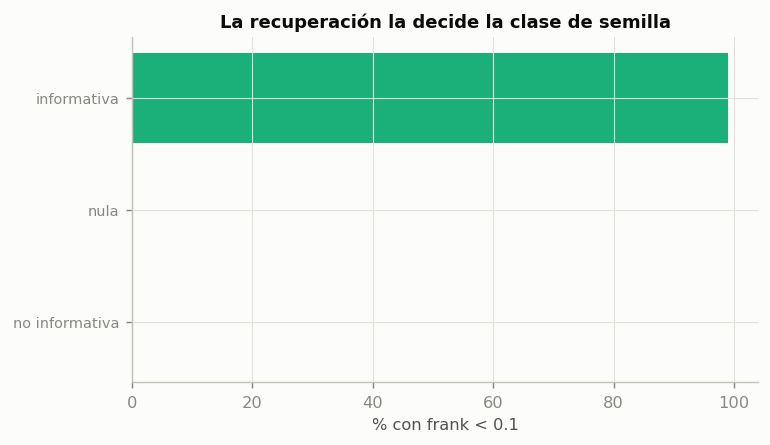

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.5), tight_layout=True)
r = resumen[resumen["particion"] == "semilla"].sort_values("pct_recuperadas")
ax.barh(range(len(r)), r["pct_recuperadas"],
        color=[tdr.COLOR_SEMILLA.get(v, tdr.MUTED) for v in r["valor"]])
ax.set_yticks(range(len(r))); ax.set_yticklabels(r["valor"], fontsize=8)
ax.set_xlabel("% con frank < 0.1")
ax.set_title("La recuperación la decide la clase de semilla")
tdr.guardar(fig, f"{NB}_f04_recuperacion_por_semilla", FIGURAS)